# 02 - Exploratory Data Analysis

## MLB Ballpark Effects on Pitch Type Frequency & Contact Quality

### May 2026

This notebook explores structure, distributions, and early signals of the 174,000 swing observations collected in `01_data_pipeline.ipynb`.  
<br>
No formal analysis or conclusions are drawn here, the goal is **better understanding and literacy of our pulled and sampled data**. Observations noted here directly inform further constructions and formal analytical layers following.



___
## 1) Data Loading & Cleaning Decisions

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


# Load pooled sample
df = pd.read_csv(r"C:\Users\Bryce Gelarden\OneDrive - Indiana University\Documents\Github - brycemgelarden\MLB_Ballpark_Factor_Analysis\data\final\mlb_pooled_sample.csv")

print("Shape: ", df.shape)
print("\nColumn Names: ")
print(df.columns.tolist())
print("\nData Types: ")
print(df.dtypes)

df.head()

Shape:  (174000, 12)

Column Names: 
['season', 'game_date', 'home_team', 'pitch_type', 'pitch_category', 'description', 'swing_outcome', 'launch_speed', 'launch_angle', 'stand', 'p_throws', 'release_speed']

Data Types: 
season              int64
game_date             str
home_team             str
pitch_type            str
pitch_category        str
description           str
swing_outcome         str
launch_speed      float64
launch_angle      float64
stand                 str
p_throws              str
release_speed     float64
dtype: object


,season,game_date,home_team,pitch_type,pitch_category,description,swing_outcome,launch_speed,launch_angle,stand,p_throws,release_speed
0,2023,2023-08-09,AZ,FC,Fastball,hit_into_play,in_play,92.1,43.0,L,R,92.6
1,2023,2023-09-20,AZ,KC,Breaking,hit_into_play,in_play,93.0,22.0,L,R,85.3
2,2023,2023-07-07,AZ,FF,Fastball,foul,foul,84.8,31.0,R,R,94.5
3,2023,2023-07-06,AZ,CU,Breaking,foul,foul,67.0,59.0,L,R,81.9
4,2023,2023-08-21,AZ,FS,Offspeed,swinging_strike_blocked,whiff,NaN,NaN,L,R,86.0


In [24]:
# Change game_date from string --> datetime variable
df['game_date'] = pd.to_datetime(df['game_date'])


# Remove knuckleballs and Statcast unclassified pitches
# KN (n=115) behaves unlike any other pitch type — exclusion justified
# NaN pitch_category (n=748) could not be classified by Statcast — excluded

df = df[df['pitch_category'].notna()].reset_index(drop=True)
working_set = len(df)

#
print(f"Working dataset:     {working_set:,} swings")

Working dataset:     173,137 swings


### Setting Up SQLite Database

In [25]:
import sqlite3
from pathlib import Path

# Connect to database
DB_PATH = Path(r"C:\Users\Bryce Gelarden\OneDrive - Indiana University\Documents\Github - brycemgelarden\MLB_Ballpark_Factor_Analysis\database\mlb_ballpark_effects.db")
DB_PATH.parent.mkdir(parents = True, exist_ok = True)

conn = sqlite3.connect(DB_PATH)

# Write working dataset over to SQLite
df.to_sql('swings', conn, if_exists = 'replace', index = False)

print(f"Database created at: {DB_PATH}")
print(f"Table 'swings' written: {len(df):,} rows")



Database created at: C:\Users\Bryce Gelarden\OneDrive - Indiana University\Documents\Github - brycemgelarden\MLB_Ballpark_Factor_Analysis\database\mlb_ballpark_effects.db
Table 'swings' written: 173,137 rows


___
## 2) Sample Integrity Check (SQL)

Confirming that all 29 parks intended for sample are present and each contribute close to 6,000 swings.

In [26]:
query = """
    SELECT
        home_team,
        COUNT(*) as swing_count
    FROM swings
    GROUP BY home_team
    ORDER BY swing_count DESC
"""

ballpark_counts = pd.read_sql_query(query, conn)

print(f"Parks present: {len(ballpark_counts)} / 29")
print(f"\nSwings per park:")
print(ballpark_counts.to_string(index=False))
print(f"\nMin:  {ballpark_counts['swing_count'].min():,}")
print(f"Max:  {ballpark_counts['swing_count'].max():,}")
print(f"Mean: {ballpark_counts['swing_count'].mean():,.2f}")


# Listing parks that came in < 6,000


Parks present: 29 / 29

Swings per park:
home_team  swing_count
      PIT         6000
      MIN         6000
      TOR         5999
      NYY         5999
      NYM         5998
      MIA         5998
       AZ         5996
      COL         5994
      PHI         5993
      STL         5992
      TEX         5990
      LAD         5988
       TB         5981
      HOU         5978
      LAA         5973
      CLE         5970
       SF         5966
      DET         5965
      CWS         5964
      BAL         5957
      BOS         5955
      CIN         5953
      WSH         5948
       SD         5948
       KC         5948
      SEA         5944
      ATL         5927
      CHC         5910
      MIL         5903

Min:  5,903
Max:  6,000
Mean: 5,970.24



**All 29 parks are present (obviously) and within 97 swings of the 6,000 swing sample target - going to be a variance of less than 2 %.**
<br><br>
Slight shortfallings at certain parks are due to removing knuckleballs (*n=115*) and 'unclassified' pitches (*n = 748*) while cleaning.  We can confirm sample integrity across all measured parks.

___
## 3) Pitch Category Distribution

League-wide pitch category distribution:
pitch_category  count   pct
      Fastball  96689 55.85
      Breaking  51650 29.83
      Offspeed  24798 14.32


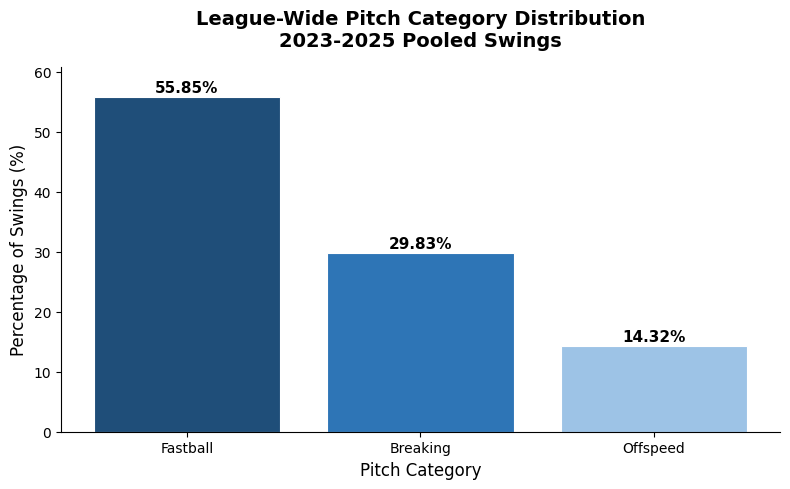

In [27]:
query = """
    SELECT
        pitch_category,
        COUNT(*) as count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pct
    FROM swings
    GROUP BY pitch_category
    ORDER BY count DESC
"""

pitch_distrib = pd.read_sql_query(query, conn)
print("League-wide pitch category distribution:")
print(pitch_distrib.to_string(index=False))


# Visualization
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#1F4E79', '#2E75B6', '#9DC3E6']

ax.bar(pitch_distrib['pitch_category'], 
       pitch_distrib['pct'],
       color=colors,
       edgecolor='white',
       linewidth=0.8)

ax.set_title('League-Wide Pitch Category Distribution\n2023-2025 Pooled Swings', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Pitch Category', fontsize=12)
ax.set_ylabel('Percentage of Swings (%)', fontsize=12)

for bar, pct in zip(ax.patches, pitch_distrib['pct']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{pct}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0, pitch_distrib['pct'].max() + 5)
sns.despine()
plt.tight_layout()
plt.show()

Fastballs dominate swing events across the 2023-2025 sample, accounting for largest share at **55.85%**. Breaking balls represent the second most common swing event (**29.83%**), with Offspeed pitches considerably trailing (**14.32%**).
<br><br>
The league-wide baseline will serve as a strong point of reference distribution when examining pitch frequencies at the individual park level.
<br><br>
<br><br>
*We can also take a closer look at individual pitch types below ...*

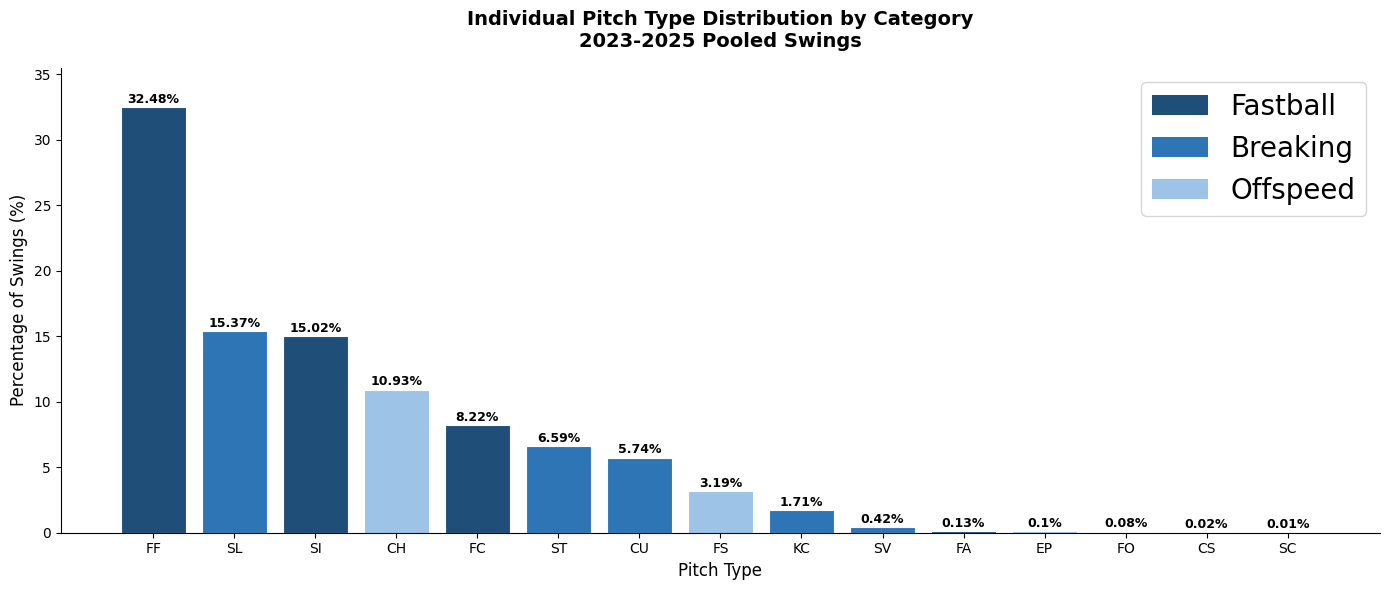

Pitch Type Key:
------------------------------
  FF:  Four-Seam Fastball
  SL:  Slider
  SI:  Sinker
  CH:  Changeup
  FC:  Cutter
  ST:  Sweeper
  CU:  Curveball
  FS:  Splitter
  KC:  Knuckle Curve
  SV:  Slurve
  FA:  Fastball
  EP:  Eephus
  FO:  Forkball
  CS:  Slow Curve
  SC:  Screwball
------------------------------


In [28]:
query = """
    SELECT
        pitch_type,
        pitch_category,
        COUNT(*) as count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pct
    FROM swings
    GROUP BY pitch_type, pitch_category
    ORDER BY count DESC
"""

pitch_type_dist = pd.read_sql_query(query, conn)

# Map category colors
color_map = {
    'Fastball': '#1F4E79',
    'Breaking': '#2E75B6',
    'Offspeed': '#9DC3E6'
}

colors = pitch_type_dist['pitch_category'].map(color_map)

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(pitch_type_dist['pitch_type'],
              pitch_type_dist['pct'],
              color=colors,
              edgecolor='white',
              linewidth=0.8)

# Percentage labels
for bar, pct in zip(ax.patches, pitch_type_dist['pct']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            f'{pct}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1F4E79', label='Fastball'),
    Patch(facecolor='#2E75B6', label='Breaking'),
    Patch(facecolor='#9DC3E6', label='Offspeed')
]
ax.legend(handles=legend_elements, fontsize=20)

ax.set_title('Individual Pitch Type Distribution by Category\n2023-2025 Pooled Swings',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Pitch Type', fontsize=12)
ax.set_ylabel('Percentage of Swings (%)', fontsize=12)
ax.set_ylim(0, pitch_type_dist['pct'].max() + 3)

sns.despine()
plt.tight_layout()
plt.show()

# Pitch type key — same order as chart (count descending)
pitch_names = {
    'FF': 'Four-Seam Fastball',
    'FC': 'Cutter',
    'SI': 'Sinker',
    'FA': 'Fastball',
    'FT': 'Two-Seam Fastball',
    'SF': 'Split-Finger Fastball',
    'SL': 'Slider',
    'ST': 'Sweeper',
    'CU': 'Curveball',
    'KC': 'Knuckle Curve',
    'SV': 'Slurve',
    'CH': 'Changeup',
    'FS': 'Splitter',
    'CS': 'Slow Curve',
    'EP': 'Eephus',
    'FO': 'Forkball',
    'SC': 'Screwball',
}

print("Pitch Type Key:")
print("-" * 30)
for code in pitch_type_dist['pitch_type'].values:
    if code in pitch_names:
        print(f"  {code}:  {pitch_names[code]}")
print("-" * 30)

___
## 4) Swing Outcome Distribution
<br><br>
Every observation in this sample is a swing.  The three mutually exclusive outcomes are:
- **Whiff**: swing and miss
- **Foul**: contact, ball does NOT enter play
- **In Play**: contact, ball enters the field of play

In [29]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np
from pathlib import Path


DB_PATH = Path(r"C:\Users\Bryce Gelarden\OneDrive - Indiana University\Documents\Github - brycemgelarden\MLB_Ballpark_Factor_Analysis\database\mlb_ballpark_effects.db")

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM swings", conn)


outcome_counts = (
    df.groupby("swing_outcome", as_index=False)
      .size()
      .rename(columns={"size": "count"})
)
outcome_counts["pct"] = outcome_counts["count"] / outcome_counts["count"].sum()
outcome_counts = outcome_counts.sort_values("pct", ascending=False).reset_index(drop=True)

print(f"Total swings: {len(df):,}\n")
print(outcome_counts.to_string(index=False))

Total swings: 173,137

swing_outcome  count      pct
         foul  65205 0.376609
      in_play  63777 0.368361
        whiff  44155 0.255029


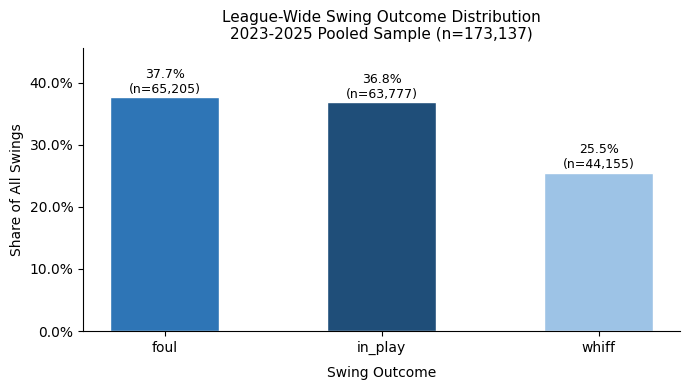

In [30]:
OUTCOME_COLORS = {
    "in_play": "#1F4E79",
    "foul":    "#2E75B6",
    "whiff":   "#9DC3E6",
}

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    outcome_counts["swing_outcome"],
    outcome_counts["pct"],
    color=[OUTCOME_COLORS[o] for o in outcome_counts["swing_outcome"]],
    width=0.5,
    edgecolor="white",
)

for bar, (_, row) in zip(bars, outcome_counts.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f"{row['pct']:.1%}\n(n={row['count']:,})",
        ha="center", va="bottom", fontsize=9
    )

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0, outcome_counts["pct"].max() + 0.08)
ax.set_xlabel("Swing Outcome", labelpad=8)
ax.set_ylabel("Share of All Swings")
ax.set_title("League-Wide Swing Outcome Distribution\n2023-2025 Pooled Sample (n=173,137)", fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

### Swing Outcome Rates by Pitch Category (Tier 1)

swing_outcome    foul in_play  whiff
pitch_category                      
Breaking        32.5%   34.9%  32.6%
Fastball        42.2%   37.6%  20.2%
Offspeed        30.8%   37.8%  31.5%


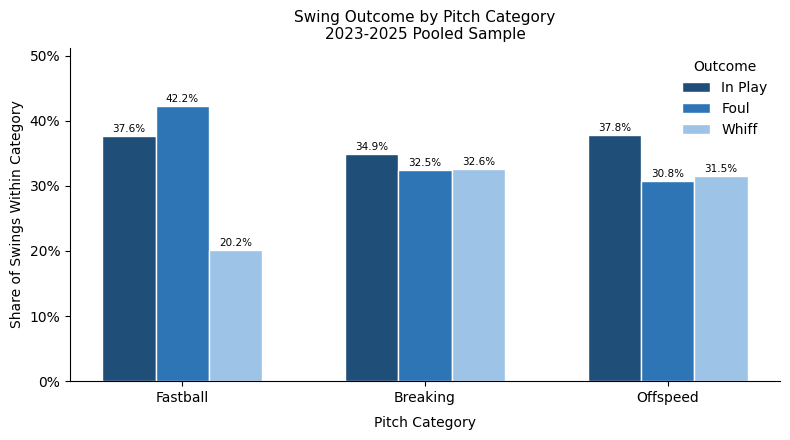

In [31]:
# Outcome rates by pitch category
cat_outcome = (
    df.groupby(["pitch_category", "swing_outcome"])
      .size()
      .reset_index(name="n")
)
cat_total = df.groupby("pitch_category").size().reset_index(name="total")
cat_outcome = cat_outcome.merge(cat_total, on="pitch_category")
cat_outcome["pct"] = cat_outcome["n"] / cat_outcome["total"]


print(cat_outcome.pivot(index="pitch_category", columns="swing_outcome", values="pct")
                 .map(lambda x: f"{x:.1%}") 
                 .to_string())

CAT_ORDER    = ["Fastball", "Breaking", "Offspeed"]
OUTCOME_ORDER = ["in_play", "foul", "whiff"]

pivot = cat_outcome.pivot(index="pitch_category", columns="swing_outcome", values="pct")
pivot = pivot.loc[CAT_ORDER, OUTCOME_ORDER]

x = np.arange(len(CAT_ORDER))
width = 0.22

fig, ax = plt.subplots(figsize=(8, 4.5))

for i, outcome in enumerate(OUTCOME_ORDER):
    bars = ax.bar(
        x + (i - 1) * width,
        pivot[outcome],
        width=width,
        label=outcome.replace("_", " ").title(),
        color=OUTCOME_COLORS[outcome],
        edgecolor="white",
    )
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f"{bar.get_height():.1%}",
            ha="center", va="bottom", fontsize=7.5
        )

ax.set_xticks(x)
ax.set_xticklabels(CAT_ORDER)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0, pivot.values.max() + 0.09)
ax.set_xlabel("Pitch Category", labelpad=8)
ax.set_ylabel("Share of Swings Within Category")
ax.set_title("Swing Outcome by Pitch Category\n2023-2025 Pooled Sample", fontsize=11)
ax.legend(title="Outcome", frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

We see that in our pooled sample, by count, foul balls are the most common swing type at **37.7%**, and further coherent to the proportion you would find if analyzing a 'true population' of Major League Baseball swing outcomes.  In Play outcomes follow at **36.8%** of our pooled sample, and we see a whiff rate of **25.5%**.
<br><br>
When we start analyzing swing outcomes by pitch groupings, things get interesting.  Notably, batter whiff rate is drastically lower when facing fastballs.  Breaking and Offspeed categories look very, very similar in aggregate in the chart above.

___
## 5) Exit Velocity & Launch Angle Distributions
Exit Velocity (EV) and Launch Angle (LA) are the two inputs we will use to construct our own SOV metric in `03_sov_construction.ipynb`.  Prior to building SOV, we need a solid understanding of the shape, and outlier of each variable withing the in-play subset.
<br><br>
*This section is purely descriptive, no park-level comparisons yet*

In [32]:
# SOV-eligible pool is 'in_play' swings only
# Whiffs and fouls carry null EV/LA --> exclude
in_play = df.query("swing_outcome == 'in_play'").copy()

print(f"Total swings:       {len(df):,}")
print(f"In-play subset:     {len(in_play):,}  ({len(in_play)/len(df):.2%} of sample)")
print(f"Non-in-play:        {len(df) - len(in_play):,}")

Total swings:       173,137
In-play subset:     63,777  (36.84% of sample)
Non-in-play:        109,360


In [33]:
# Summary statistics on EV and LA on in-play subset (still null values for auditing in a moment)
ev_la_summary = in_play[["launch_speed", "launch_angle"]].describe().T
ev_la_summary.columns = ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
ev_la_summary = ev_la_summary.round(2)

print(ev_la_summary.to_string())


                count   mean    std   min   25%   50%   75%    max
launch_speed  63626.0  88.54  14.93   9.6  80.1  91.5  99.7  120.3
launch_angle  63655.0  12.99  28.79 -89.0  -5.0  14.0  31.0   89.0


This output at first glance indicates there are no null values in in_play swings with each variable's 'min' output being possible.  The following code will disprove that.

In [34]:
print(f"In-play observations:        {len(in_play):,}")
print(f"EV non-null:                 {in_play['launch_speed'].notna().sum():,}")
print(f"LA non-null:                 {in_play['launch_angle'].notna().sum():,}")
print(f"Both EV and LA non-null:     {in_play[['launch_speed','launch_angle']].dropna().shape[0]:,}")
print(f"Missing EV or LA (any):      {in_play[['launch_speed','launch_angle']].isna().any(axis=1).sum():,}")

In-play observations:        63,777
EV non-null:                 63,626
LA non-null:                 63,655
Both EV and LA non-null:     63,625
Missing EV or LA (any):      152


In [35]:
# dropping out nulls, ensuring both EV and LA have none on each unit of measurement (swing)
in_play = in_play.dropna(subset=["launch_speed", "launch_angle"]).copy()
print(f"SOV-eligible observations: {len(in_play):,}")

SOV-eligible observations: 63,625


### Exit Velocity (EV) Distribution:

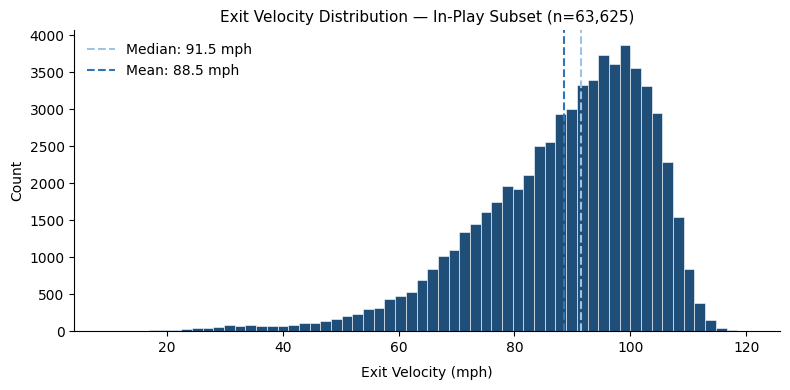

In [36]:
ev_clean = in_play["launch_speed"].dropna()

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(ev_clean, bins=60, color="#1F4E79", edgecolor="white", linewidth=0.4)

ax.axvline(ev_clean.median(), color="#9DC3E6", linewidth=1.5,
           linestyle="--", label=f"Median: {ev_clean.median():.1f} mph")
ax.axvline(ev_clean.mean(), color="#2E75B6", linewidth=1.5,
           linestyle="--", label=f"Mean: {ev_clean.mean():.1f} mph")

ax.set_xlabel("Exit Velocity (mph)", labelpad=8)
ax.set_ylabel("Count")
ax.set_title(f"Exit Velocity Distribution — In-Play Subset (n={len(ev_clean):,})", fontsize=11)
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

### Launch Angle (LA) Distribution:

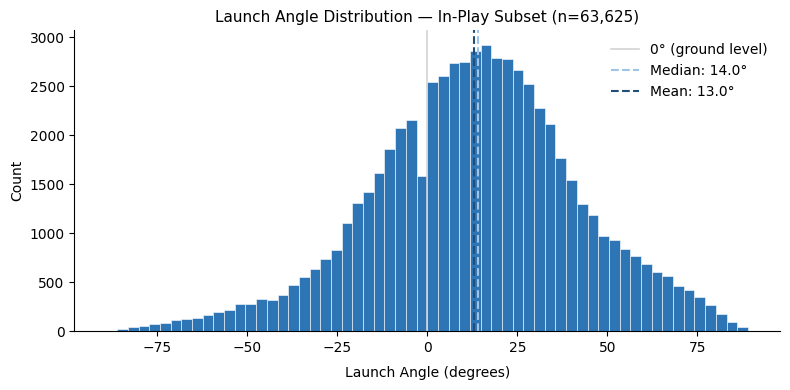

In [37]:
la_clean = in_play["launch_angle"].dropna()

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(la_clean, bins=60, color="#2E75B6", edgecolor="white", linewidth=0.4)

ax.axvline(0, color="lightgray", linewidth=1.2, linestyle="-", label="0° (ground level)")
ax.axvline(la_clean.median(), color="#9DC3E6", linewidth=1.5,
           linestyle="--", label=f"Median: {la_clean.median():.1f}°")
ax.axvline(la_clean.mean(), color="#1F4E79", linewidth=1.5,
           linestyle="--", label=f"Mean: {la_clean.mean():.1f}°")

ax.set_xlabel("Launch Angle (degrees)", labelpad=8)
ax.set_ylabel("Count")
ax.set_title(f"Launch Angle Distribution — In-Play Subset (n={len(la_clean):,})", fontsize=11)
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

### Joint Scatter (x = EV, y = LA)

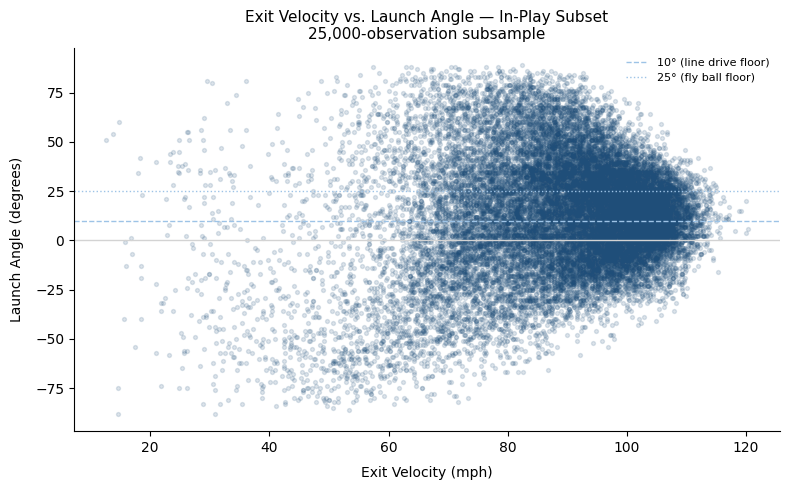

In [38]:
# Joint scatter — random subsample for readability, full dataset too dense to plot

plot_sample = in_play[["launch_speed", "launch_angle"]].dropna().sample(25000, random_state=2005)
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    plot_sample["launch_speed"],
    plot_sample["launch_angle"],
    alpha=0.15, s=8, color="#1F4E79"
)

ax.axhline(0, color="lightgray", linewidth=1.0, linestyle="-")
ax.axhline(10, color="#9DC3E6", linewidth=1.0, linestyle="--", label="10° (line drive floor)")
ax.axhline(25, color="#9DC3E6", linewidth=1.0, linestyle=":",  label="25° (fly ball floor)")

ax.set_xlabel("Exit Velocity (mph)", labelpad=8)
ax.set_ylabel("Launch Angle (degrees)", labelpad=8)
ax.set_title("Exit Velocity vs. Launch Angle — In-Play Subset\n25,000-observation subsample", fontsize=11)
ax.legend(frameon=False, fontsize=8)
sns.despine()
plt.tight_layout()
plt.show()

Exit velocity across our SOV-eligible sample (n=63,625) is **left-skewed**, w/ a median 
of **91.5 mph** and mean of **88.5 mph** — the gap between the two driven by a thin but 
real tail of weakly-struck contact pulling the mean down. The mass of contact clusters 
between roughly 75–105 mph reflect a physical ceiling on how hard a major leaguer 
can hit a baseball.

Launch angle tells the more interesting story. Despite being, in theory, unconstrained 
from -90° to 90°, the distribution is **strikingly normal**, centered at a median of **14°** 
and mean of **13°**. Likely not coincidental, instead offensive philosophy baked in to our results.
The past decade's launch angle revolution has led MLB hitters to deliberately swing planes 
toward the 10–25 band associated with line drives and fly balls (more XBHs). 

Both distributions are well-behaved entering SOV construction, no transformations required.

___
## Closing

This notebook established the analytical foundation for the three-layer park effects framework. 
Key takeaways entering the modeling phase:

- **Sample integrity confirmed** — 173,137 swings across 29 parks, variance under 2% from target
- **Pitch landscape documented** — Fastballs dominate at 55.8% of swings, with the Sweeper (ST) 
  emerging as a modern era signal at 6.6% of all swings
- **Swing outcome baseline set** — 25.5% whiff rate league-wide, with fastballs generating 
  markedly less swing-and-miss but more foul ball contact than breaking or offspeed offerings
- **SOV-eligible sample locked** — 63,625 in-play observations with both EV and LA present, 
  152 Statcast tracking gaps dropped (<0.25% of in-play contact)
- **Input distributions validated** — exit velocity and launch angle are well-behaved entering 
  SOV construction, with launch angle's near-normality reflecting the deliberate swing plane 
  optimization that has defined the modern MLB hitter

The next notebook (`03_sov_construction.ipynb`) builds the Swing Output Value metric — 
a continuous [-1, 1] scale measuring contact quality independent of park environment. 
SOV is the analytical core of this project. Everything from notebook 4 onward depends on it.